# 25SC2107E – Machine Learning (Skilling) Lab Manual
## Heart Disease — Random Forest Ensemble
Dataset: Heart Disease (Cleveland) | Course Outcome: CO3 | Environment: VS Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
heart = pd.read_csv("heart.csv")
X = heart.drop(columns="target")
y = heart["target"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(212, 13) (45, 13) (46, 13)


In [3]:
best_depth, best_acc = None, -1.0
for d in range(1, 21):
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    acc = accuracy_score(y_val, t.predict(X_val))
    if acc > best_acc:
        best_acc, best_depth = acc, d

one_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
one_tree.fit(X_train, y_train)
print("best depth:", best_depth)
print("one tree val %.4f test %.4f" % (
    accuracy_score(y_val, one_tree.predict(X_val)),
    accuracy_score(y_test, one_tree.predict(X_test))))

best depth: 4
one tree val 0.8000 test 0.7609


In [4]:
rng = np.random.RandomState(42)
n = len(X_train)
predictions = []

for i in range(5):
    idx = rng.choice(n, n, replace=True) # bootstrap sample
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train.iloc[idx], y_train.iloc[idx])
    p = tree.predict(X_val)
    predictions.append(p)
    print("tree %d val %.4f distinct rows used %d" % (
        i + 1, accuracy_score(y_val, p), len(np.unique(idx))))

votes = np.array(predictions).mean(axis=0)
bagged = (votes >= 0.5).astype(int)
print("5 trees voting together: val %.4f" % accuracy_score(y_val, bagged))

tree 1 val 0.7333 distinct rows used 128
tree 2 val 0.7111 distinct rows used 127
tree 3 val 0.7111 distinct rows used 134
tree 4 val 0.7111 distinct rows used 140
tree 5 val 0.6889 distinct rows used 134
5 trees voting together: val 0.8000


n=1    oob 0.5236 val 0.7778
n=5    oob 0.6934 val 0.8222


C:\Users\vshre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\vshre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n=10   oob 0.7594 val 0.7778


n=25   oob 0.8019 val 0.7778


n=50   oob 0.8019 val 0.7778


n=100  oob 0.8113 val 0.8000


n=200  oob 0.8208 val 0.8222


n=300  oob 0.8349 val 0.8222


n=500  oob 0.8302 val 0.8222


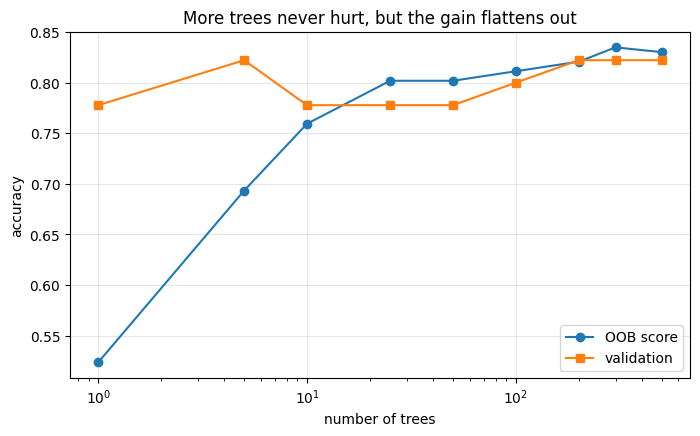

In [5]:
sizes = [1, 5, 10, 25, 50, 100, 200, 300, 500]
oob_scores, val_scores = [], []

for k in sizes:
    rf = RandomForestClassifier(n_estimators=k, oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    val_scores.append(accuracy_score(y_val, rf.predict(X_val)))
    print("n=%-4d oob %.4f val %.4f" % (k, rf.oob_score_, val_scores[-1]))

plt.figure(figsize=(8, 4.5))
plt.plot(sizes, oob_scores, marker="o", label="OOB score")
plt.plot(sizes, val_scores, marker="s", label="validation")
plt.xscale("log")
plt.xlabel("number of trees")
plt.ylabel("accuracy")
plt.title("More trees never hurt, but the gain flattens out")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

max_features 1      val 0.8222


max_features 2      val 0.8222


max_features 3      val 0.8222


max_features sqrt   val 0.8222


max_features 5      val 0.7778


max_features 7      val 0.8000


max_features 9      val 0.8000


max_features 11     val 0.7778


max_features 13     val 0.8000


max_features None   val 0.8000


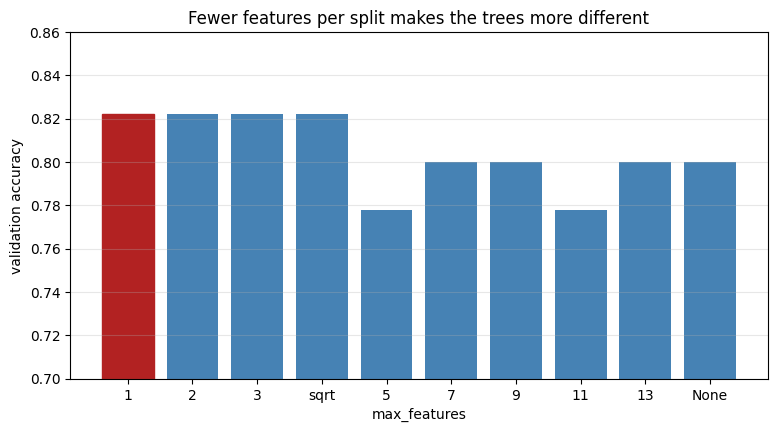

In [6]:
options = [1, 2, 3, "sqrt", 5, 7, 9, 11, 13, None]
scores = []

for mf in options:
    rf = RandomForestClassifier(n_estimators=200, max_features=mf, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    scores.append(accuracy_score(y_val, rf.predict(X_val)))
    print("max_features %-6s val %.4f" % (str(mf), scores[-1]))

labels = [str(o) for o in options]
plt.figure(figsize=(9, 4.5))
bars = plt.bar(labels, scores, color="steelblue")
bars[int(np.argmax(scores))].set_color("firebrick")
plt.ylim(0.70, 0.86)
plt.xlabel("max_features")
plt.ylabel("validation accuracy")
plt.title("Fewer features per split makes the trees more different")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [7]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, oob_score=True)
rf.fit(X_train, y_train)

print("forest train %.4f val %.4f test %.4f oob %.4f" % (
    accuracy_score(y_train, rf.predict(X_train)),
    accuracy_score(y_val, rf.predict(X_val)),
    accuracy_score(y_test, rf.predict(X_test)),
    rf.oob_score_))
print("one tree val %.4f test %.4f" % (
    accuracy_score(y_val, one_tree.predict(X_val)),
    accuracy_score(y_test, one_tree.predict(X_test))))
print(confusion_matrix(y_test, rf.predict(X_test)))

forest train 1.0000 val 0.8222 test 0.8043 oob 0.8208
one tree val 0.8000 test 0.7609
[[15  6]
 [ 3 22]]


            gini  permutation
age       0.0783      -0.0007
ca        0.0683       0.0385
chol      0.0723       0.0111
cp        0.1642       0.0474
exang     0.0613       0.0037
fbs       0.0088       0.0074
oldpeak   0.1295       0.0259
restecg   0.0189       0.0000
sex       0.0276       0.0585
slope     0.0642      -0.0000
thal      0.1179       0.0319
thalach   0.1150       0.0081
trestbps  0.0737       0.0222


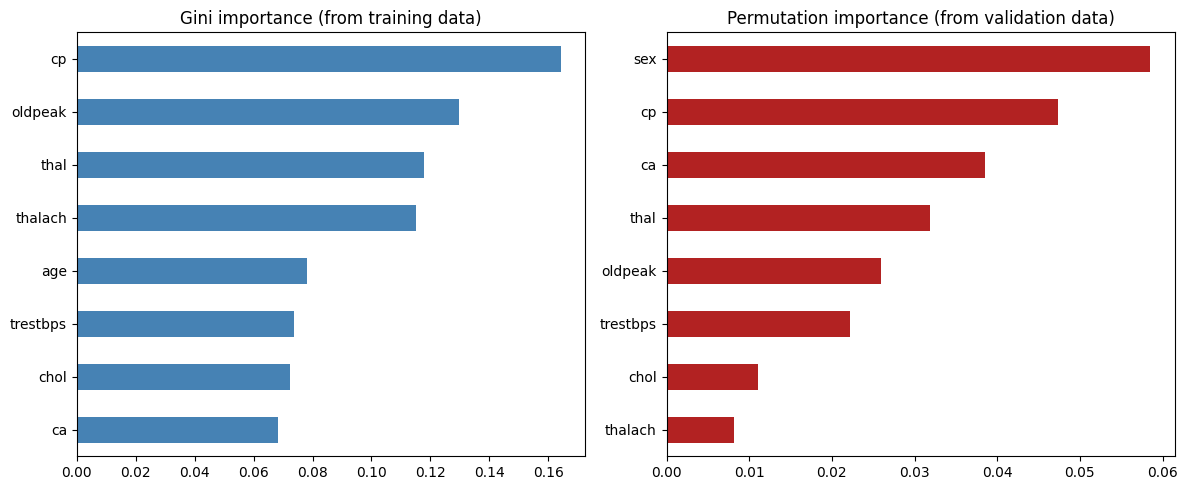

In [8]:
gini_rank = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

result = permutation_importance(rf, X_val, y_val, n_repeats=30, random_state=42)
perm_rank = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

compare = pd.DataFrame({"gini": gini_rank, "permutation": perm_rank})
print(compare.round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
gini_rank.head(8)[::-1].plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title("Gini importance (from training data)")
perm_rank.head(8)[::-1].plot.barh(ax=ax[1], color="firebrick")
ax[1].set_title("Permutation importance (from validation data)")
plt.tight_layout()
plt.show()

In [9]:
def ensemble_comparison(X_train, y_train, X_val, y_val):
    rows = []

    # 1. single decision tree at its best depth
    best_depth, best_acc = None, -1.0
    for d in range(1, 21):
        t = DecisionTreeClassifier(max_depth=d, random_state=42)
        t.fit(X_train, y_train)
        acc = accuracy_score(y_val, t.predict(X_val))
        if acc > best_acc:
            best_acc, best_depth = acc, d
    rows.append({"model": "DecisionTree", "n_trees": 1,
                 "val_accuracy": round(best_acc, 4)})

    # 2. bagging built by hand with 10 trees
    rng = np.random.RandomState(42)
    n = len(X_train)
    predictions = []
    for _ in range(10):
        idx = rng.choice(n, n, replace=True)
        t = DecisionTreeClassifier(random_state=42)
        t.fit(X_train.iloc[idx], y_train.iloc[idx])
        predictions.append(t.predict(X_val))
    vote = (np.array(predictions).mean(axis=0) >= 0.5).astype(int)
    rows.append({"model": "Manual Bagging", "n_trees": 10,
                 "val_accuracy": round(accuracy_score(y_val, vote), 4)})

    # 3. random forest with 200 trees
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rows.append({"model": "RandomForest", "n_trees": 200,
                 "val_accuracy": round(accuracy_score(y_val, rf.predict(X_val)), 4)})

    return (pd.DataFrame(rows)
            .sort_values("val_accuracy", ascending=False)
            .reset_index(drop=True))

table = ensemble_comparison(X_train, y_train, X_val, y_val)
table

,model,n_trees,val_accuracy
0,RandomForest,200,0.8222
1,DecisionTree,1,0.8000
2,Manual Bagging,10,0.7778
